# `wisesight-sentiment` Data Exploration by [@lukkiddd](https://github.com/lukkiddd)

This notebook perform an exploration of the `wisesight-sentiment` dataset which was provided by **Wisesight (Thailand) Co., Ltd**. It contains 24,063 texts with 4 categories (`q`uestion, `neg`ative, `neu`tral, and `pos`itive) for training set and 2,674 texts for test set. For more detail about the data you can read `README.md` at https://github.com/PyThaiNLP/wisesight-sentiment .
    
- Word length distribution
- TF-IDF
    - Words
    - Emojis
    - Punctuations
    - URLs
    - Hashtags

In [1]:
import re

import pandas as pd

from pathlib import Path

from pythainlp.tokenize import word_tokenize
from tqdm import tqdm_notebook

# For visualization
import seaborn as sns

from matplotlib import pyplot as plt

# params
pd.set_option("max_colwidth", 0)
sns.set_context("talk")
sns.set_palette(sns.color_palette("colorblind", 10))

%matplotlib inline

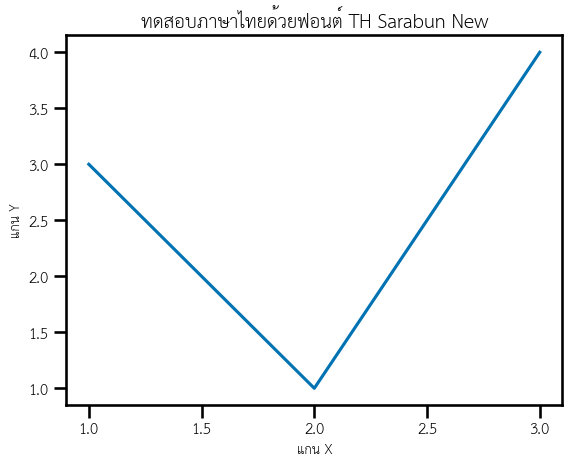

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 🔹 ใส่พาธไปยังไฟล์ฟอนต์ของคุณ
path = r"C:\THSarabunNew.ttf"  # 👈 เปลี่ยนตามจริง
# ถ้าอยู่ในโฟลเดอร์เดียวกับไฟล์ Python ใช้แค่:
# font_path = "THSarabunNew.ttf"

# ✅ ตรวจสอบว่าไฟล์มีอยู่จริง
import os
if not os.path.exists(path):
    raise FileNotFoundError(f"❌ ไม่พบไฟล์ฟอนต์ที่ {path}")

# ✅ ลงทะเบียนฟอนต์ใน matplotlib
font_manager.fontManager.addfont(path)
rcParams["font.family"] = "TH Sarabun New"

# ✅ ทดสอบการพล็อตกราฟภาษาไทย
plt.title("ทดสอบภาษาไทยด้วยฟอนต์ TH Sarabun New", fontsize=20)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xlabel("แกน X", fontsize=14)
plt.ylabel("แกน Y", fontsize=14)
plt.show()


# Reading data

In [3]:
# Set data path
data_folder = Path("kaggle-competition/")

In [4]:
#แปลงชุดข้อมูลการฝึก (Training Dataset) ที่เดิมแยกเก็บเป็นไฟล์ข้อความสำหรับข้อความและป้ายกำกับ ให้กลายเป็น ไฟล์ตาราง .csv ที่พร้อมใช้งานสำหรับการประมวลผลและการฝึกโมเดลต่อไป.
import pandas as pd
from pathlib import Path

data_folder = Path("C:/wisesight-sentiment-master/kaggle-competition")  

texts = []
labels = []


with open(data_folder / "train.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

with open(data_folder / "train_label.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(line.strip())

df = pd.DataFrame({
    "category": labels,
    "texts": texts
})

df.to_csv("_train.csv", index=False, encoding="utf-8-sig")  
print(df.shape)


(24063, 2)


In [5]:
# Generate _test.csv from test.txt, use "neu" as the only class
texts = []
labels = []

with open(data_folder / "test.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

test_df = pd.DataFrame({
    "category": "neu",
    "texts": texts
})

test_df.to_csv("_test.csv", index=False, encoding="utf-8-sig") 
print(test_df.shape)


(2674, 2)


In [6]:
df.describe()
# count	จำนวนข้อมูลที่ไม่ใช่ค่าว่าง
# unique	จำนวนค่าที่ไม่ซ้ำกัน 
# top	ค่าที่ปรากฏบ่อยที่สุด 
# freq	ความถี่ของค่าที่ปรากฏบ่อยที่สุด 

,category,texts
count,24063,24063
unique,4,24014
top,neu,#ERROR!
freq,13105,31


In [7]:
df.groupby("category").describe()
# neg	Negativeเชิงลบ 
# neu	Neutralเป็นกลาง 
# pos	Positiveเชิงบวก 
# q	Questionคำถาม 

texts         \
          count unique   
category                 
neg       6140   6129    
neu       13105  13087   
pos       4300   4300    
q         518    518     

                                                                                       \
                                                                                  top   
category                                                                                
neg       #ERROR!                                                                       
neu       #ERROR!                                                                       
pos       สนใจ ฟอจูนเนอร์ สีขาวครับ                                                     
q         นิสสัน suv ที่เพิ่งเปิดตัวที่ฟิลิบปินส์เป็นไงบ้างครับ สมรรถภาพ มาไทยเมื่อไร   

               
         freq  
category       
neg       12   
neu       19   
pos       1    
q         1

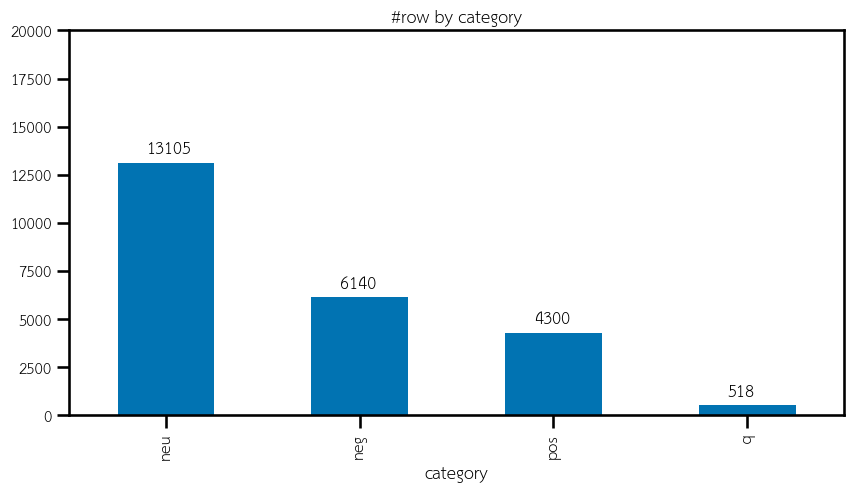

In [8]:
row_count_by_category = df.category.value_counts()

# แก้ไขตรงนี้: เปลี่ยน "bar" เป็น kind="bar"
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))

ax.set_ylim(0, 20000)
for i, label in enumerate(row_count_by_category):
    # ปรับตำแหน่ง label ให้เหมาะสมกับบาร์
    ax.annotate(str(label), (i - 0.1, label + 500))

# Text length

In [9]:
#ตรวจนับจำนวนคำในแต่ละข้อความครับ
df["length"] = df["texts"].apply(word_tokenize).apply(len)
df.head()

,category,texts,length
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ,13
1,neu,คะ,1
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,9
3,neu,😅😅😅,1
4,neu,สวัสดีวันพุธ แนน อะไรนะ,8


<Axes: >

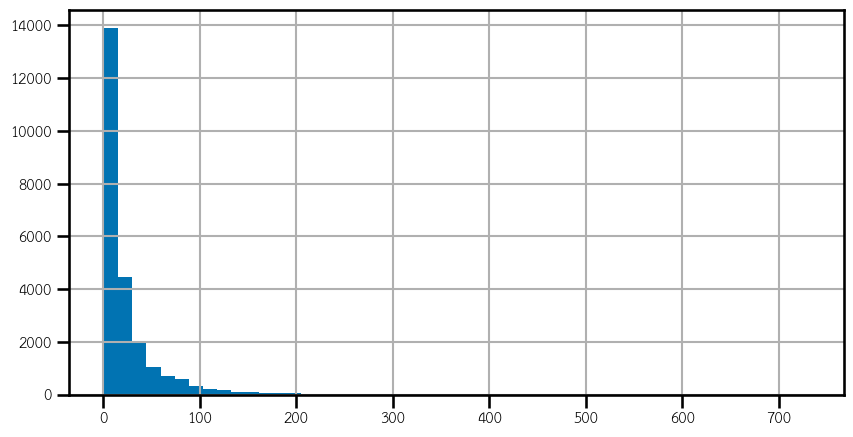

In [10]:
#วิเคราะห์ความยาวข้อความใน DataFrame ด้วยการสร้าง Histogram ครับ
df["length"].hist(bins=50, figsize=(10, 5))

In [42]:
import pandas as pd

# คำนวณสถิติ
desc = df['length'].describe()

# สร้างตารางพร้อมคำอธิบาย
table_data = [
    ["count", int(desc['count']), "จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้"],
    ["mean", round(desc['mean'], 2), "ค่าเฉลี่ยของจำนวนคำต่อข้อความ"],
    ["std", round(desc['std'], 2), "ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ"],
    ["min", int(desc['min']), "ข้อความที่สั้นที่สุด"],
    ["25%", int(desc['25%']), "25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)"],
    ["50%", int(desc['50%']), "Median ของความยาวข้อความ (ค่ากลาง)"],
    ["75%", int(desc['75%']), "75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)"],
    ["max", int(desc['max']), "ข้อความที่ยาวที่สุด"]
]

# สร้าง DataFrame
summary_table = pd.DataFrame(table_data, columns=["ค่าที่ได้", "ค่า", "ความหมาย"])

# แสดงตาราง
summary_table



,ค่าที่ได้,ค่า,ความหมาย
0,count,24063.00,จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้
1,mean,26.46,ค่าเฉลี่ยของจำนวนคำต่อข้อความ
2,std,43.03,ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ
3,min,1.00,ข้อความที่สั้นที่สุด
4,25%,6.00,25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)
5,50%,12.00,Median ของความยาวข้อความ (ค่ากลาง)
6,75%,29.00,75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)
7,max,731.00,ข้อความที่ยาวที่สุด


In [12]:
df[df["length"] >= 731]

,category,texts,length
5889,neu,"และงานใหญ่ประจำปี บ้ตร sold out ทุกปี - ขายบัตรแล้ว!! พร้อมเพิ่มวง LIPTA - ถึงเวลารวม ชนเผ่า Johnnie Walker present 20Something On The Beach 2018 ""ชน เผ่า เมา เต้น"" ▶ THAITANIUM ▶ UrboyTJ ▶ COCKTAIL ▶ MILD ▶ LIPTA ▶ MUSKETEERS X BETTERWEATHER ▶ บริษัทฮาไม่จำกัด (บอล,ค่อม,ตั๊ก,โรเบิร์ต สายควัน) ▶ Dj Taidy Dj MMM Mc YongHulk ▶ GiraffNoi / RAVEN DOLL PARTY แบบ nonstop ไม่มี dead air DJ สลับ ศิลปินตลอดงาน @The Zign pattaya Sat 03/03/2018 16.00 - until late AGE : 18+ Dress Code : ชนเผ่า ----------------------------------------------- งานแบ่งเป็น 2 zone * Zone Regular : อยู่ด้านหลังไม่ติดเวที มีโต๊ะให้บางส่วน ไม่มีการจอง มาก่อนได้ก่อน ไม่ได้มีพอกับทุกคน เข้า zone vip ไม่ได้ (บัตรทุกราคา free mixer all night) * Regular Ticket - Pre sale : 900 ฿ - Door sale : 1,200 ฿ * Regular Package : 4,900฿ (ไม่มีบุ๊คโต๊ะ ไปก่อนได้ก่อน) - ห้องพัก the zign 1 ห้อง - บัตร regular 2 ใบ - บัตรอาหารเช้า 2 ท่าน — *Zone VIP : อยู่ด้านหน้าติดเวที Zone นี้ทุกโต๊ะจะต้องจองเท่านั้น สำหรับคนที่ ซื้อบัตร vip แยกเป็นใบๆ ต้องมีเพื่อนจองโต๊ะแล้วเท่านั้น ไม่งั้นเข้าไป คุณจะไม่มีโต๊ะ * VIP Ticket (limited) - 1,500 ฿ * VIP Package A : 15,000 ฿ (มีบุ๊คโต๊ะ) - ห้องพัก the zign 1 ห้อง - บัตร vip 4 ใบ - Whisky Johnnie Walker Blenders’ Batch 2 ขวด - Reserve table + VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night - บัตรอาหารเช้า 2 ท่าน * VIP Package B : 12,000 ฿ (มีบุ๊คโต๊ะ) (สำหรับคนไม่เอาห้อง) - บัตร vip 4 ใบ - Whisky Johnnie Walker Blenders’ Batch - Reserve table + VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night * VIP Package C : 6,100 ฿ (ไม่มีบุ๊คโต๊ะ) (สำหรับคนที่เพื่อนซื้อโต๊ะแล้ว) - ห้องพัก the zign 1 ห้อง - บัตร vip 2 ใบ - VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night - บัตรอาหารเช้า 2 ท่าน ----------------------------------------------- ซื้อบัตรคลิก : http://go.eventpop.me/20STHONTHEBEACH2018 ซื้อบัตรกับทางร้าน (เฉพาะโต๊ะ vip zone ครึ่งหลัง) LINE@20sth : https://goo.gl/ujgAK4 Party by ""20STH TEAM"" #20somethingonthebeach2018 #20somethingonthebeach #ชนเผ่าเมาเต้น",731


### Word length distribution

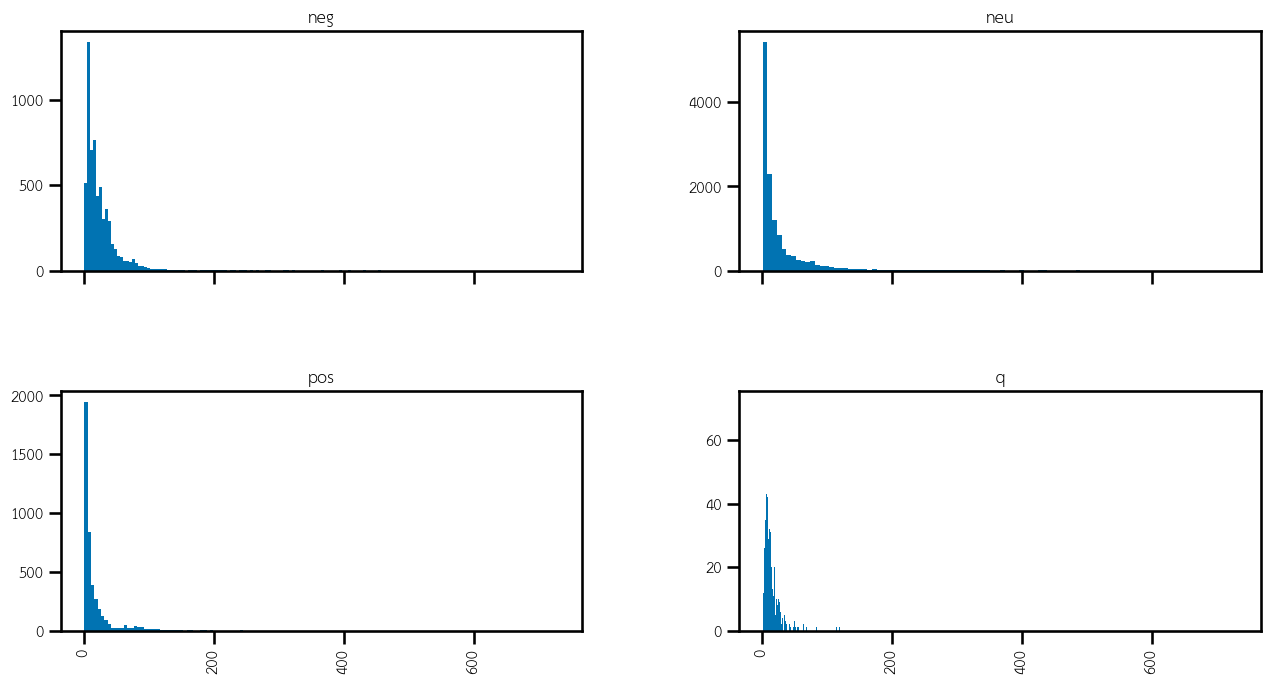

In [13]:
df.hist(column="length", by="category", bins=100, figsize=(15,8), sharex=True)
plt.show()

### Word length distribution (< 100)

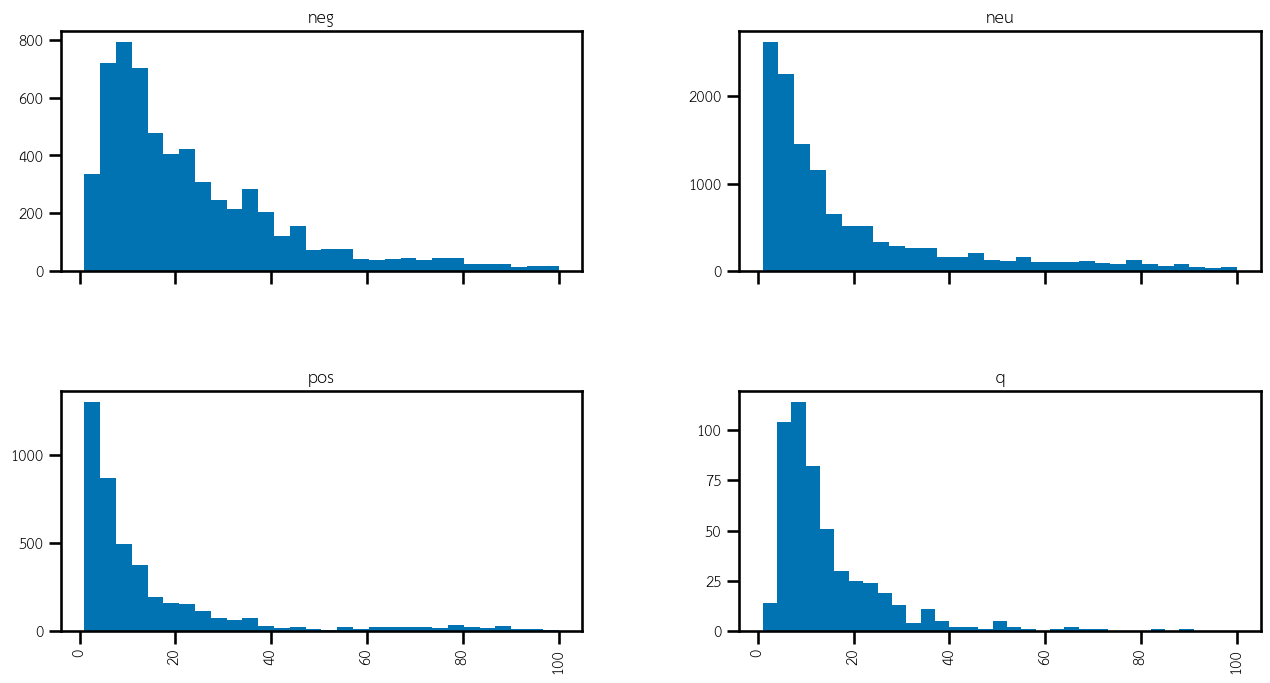

In [14]:
df[df["length"] <= 100].hist(column="length", by="category", bins=30, figsize=(15,8), sharex=True)
plt.show()

# Preprocess

In [15]:
# ฟังก์ชันนี้ทำหน้าที่เป็นตัวช่วยในการ ทำความเข้าใจ (Interpretability) โมเดล TF-IDF โดยการแสดงผลในรูปแบบที่มนุษย์อ่านและตีความได้ง่าย
def top_feats(row, features, top_n=25):
    ''' Get top n tfidf values in row and return them with their corresponding feature names.'''

    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    df = pd.DataFrame(top_feats)
    df.columns = ["feature", "score"]

    return df

In [16]:
#ระบุคำศัพท์ (Features) ที่มีความโดดเด่นและมีนัยสำคัญที่สุดโดยเฉลี่ยในกลุ่มเอกสาร
def top_mean_feats(Xtr, features, grp_ids=None, min_tfidf=0.1, top_n=25):
    ''' Return the top n features that on average are most important amongst documents in rows
        indentified by indices in grp_ids. '''

    if grp_ids:
        D = Xtr[grp_ids].toarray()
    else:
        D = Xtr.toarray()

    D[D < min_tfidf] = 0
    tfidf_means = np.mean(D, axis=0)

    return top_feats(tfidf_means, features, top_n)

In [17]:
#วิเคราะห์และแสดงคำศัพท์ (Features) ที่มีความสำคัญสูงสุดโดยเฉลี่ยสำหรับแต่ละหมวดหมู่ความรู้สึก (Sentiment Class) โดยเฉพาะ
def top_feats_by_class(Xtr, y, features, min_tfidf=0.1, top_n=25):
    ''' Return a list of dfs, where each df holds top_n features and their mean tfidf value
        calculated across documents with the same class label. '''

    dfs = []
    labels = np.unique(y)

    for label in labels:
        ids = np.where(y==label)
        feats_df = top_mean_feats(Xtr, features, ids, min_tfidf=min_tfidf, top_n=top_n)
        feats_df.label = label
        dfs.append(feats_df)

    return dfs

In [18]:
#แสดงผลข้อมูลคำศัพท์ (Features) ที่มีความสำคัญสูงสุดของแต่ละคลาสความรู้สึก
def plot_classfeats_h(dfs, score_name=''):
    ''' Plot the data frames returned by the function plot_tfidf_classfeats(). '''

    fig = plt.figure(figsize=(12, 9), facecolor="w")
    x = np.arange(len(dfs[0]))

    for i, df in enumerate(dfs):
        ax = fig.add_subplot(1, len(dfs), i+1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_frame_on(False)
        ax.get_xaxis().tick_bottom()
        ax.get_yaxis().tick_left()
        ax.set_xlabel(f"Mean {score_name} Score", labelpad=16, fontsize=14)
        ax.set_title("label = " + str(df.label), fontsize=16)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
        ax.barh(x, df.score, align='center', color='#3F5D7D')
        ax.set_yticks(x)
        ax.set_ylim([-1, x[-1]+1])
        ax.invert_yaxis()
        yticks = ax.set_yticklabels(df.feature)
        plt.subplots_adjust(bottom=0.09, right=0.97, left=0.15, top=0.95, wspace=0.52)

    plt.show()

In [19]:
#สำหรับการวิเคราะห์และแสดงผลคำศัพท์
def show_classfeats(df, vectorizer, analyzer, score_name='', text_col='texts', class_col='category', is_emoji=False):
    vec = vectorizer(analyzer=analyzer)
    mat = vec.fit_transform(df[text_col])
    dfs = top_feats_by_class(mat, df[class_col], vec.get_feature_names())

    if is_emoji:
        for dataframe in dfs:
            dataframe.columns = [dataframe.label, 'tfidf_' + dataframe.label]
        return pd.concat(dfs, axis=1)
    else:
        plot_classfeats_h(dfs, score_name=score_name)

In [20]:
#ฟังก์ชันการประมวลผลข้อความล่วงหน้าที่ใช้ในการแยกหรือกรององค์ประกอบเฉพาะจากข้อความภาษาไทย
import string
import emoji
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

def process_text(text):
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = "".join(nopunc)
    
    return [word for word in word_tokenize(nopunc) if word and not re.search(pattern=r"\s+", string=word)]

def extract_url(text):
    URL_PATTERN = r"(https?:\/\/)?\.([\da-z-]+)\.([a-z\.]{2,6})([\/\w\.-]*)*\/?\S"
    return [url[1] for url in re.findall(pattern=URL_PATTERN, string=text.lower())]

def extract_emojis(str):
    return [c for c in str if c in emoji.UNICODE_EMOJI]

def extract_punc(text):
    return [char for char in text if char in string.punctuation]

def extract_hashtags(text):
    HASHTAG_PATTERN = r"#[a-zA-Z0-9ก-๙]+"
    return re.findall(pattern=HASHTAG_PATTERN, string=text)

## TF-IDF

### Words

In [21]:
show_classfeats(
    df=df[:1000],
    vectorizer=TfidfVectorizer,
    analyzer=process_text,
    score_name="tf-idf",
)

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

### Emojis

In [ ]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_emojis)

### Punctuations

In [ ]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_punc)

### URLs

In [ ]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_url)

### Hashtags

In [ ]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_hashtags)

# Neutral, Positive, Negative

In [22]:
#เลือกตัวอย่างข้อมูลความเป็นกลาง
neu_df = df[df.category == "neu"].sample(5000)
neu_df.head()

,category,texts,length
23289,neu,ทำไม Biore UV Essence ถึงทำให้เริงร่าท้าแดดเล่นน้ำสงกรานต์เพราะเป็นครีมกันแดดให้ประสิทธิภาพการปกป้องสูงครบทั้ง UVA และ UVB และปกป้องยาวนาน ผิวไม่หมองคล้ำและป้องกันริ้วรอยก่อนวัยด้วย SPF50+/PA++++ พร้อมเนื้อเอสเซ้นส์บางเบาสุดๆ จนสามารถทาทับเครื่องสำอางระหว่างวันโดยไม่เป็นคราบ ไม่มันเหนอะหนะ และด้วยนวัตกรรมครีมกันแดดสูตรน้ำ เบาสบายผิว และใช้ได้ทุกวัน #BioreUVEssence #BioreFunInTheSun #SongkranFunFest #กันแดดกันแก่ที่ดีที่สุด #กันแดดอันดับ1จากญี่ปุ่น,110
13916,neu,สลัดๆ,2
4610,neu,เรามีเงิน กินไม่ต้องโปรก็ได้555555555555,8
6110,neu,ชมวีดีโอทีเซอร์ล่าสุด Ford Focus 2019 ก่อนเปิดตัวจริงสัปดาห์หน้า,17
20089,neu,ปัญหา ไฟหน้า ฟอร์จูนเนอร์ จะหมดไปถ้า ทำไฟสูงต่ำแยกคนละหลอด เหมือน รีโว่,22


In [23]:
#แยกเฉพาะข้อมูลที่มีความรู้สึกเป็นเชิงบวก (Positive Sentiment) ออกจาก DataFrame หลัก
pos_df = df[df.category == "pos"]
pos_df.head()

,category,texts,length
10,pos,สนใจ ฟอจูนเนอร์ สีขาวครับ,9
16,pos,ไปดิ..รอไร,5
19,pos,อยากกินบาบีก้อนหรอ555555,6
22,pos,ต้องไปลองกันนะ,5
25,pos,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เพจเยอะๆ มีสินค้าคุณภาพออกมาให้ผู้บริโภคมากๆ ให้ SHEENeดูแลคนไทยไปตลอดไปครับ,34


In [24]:
neg_df = df[df.category == "neg"]
neg_df.head()

,category,texts,length
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,9
6,neg,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ตโครตห่วยยิ่งดึกๆเน็ตยิ่งห่วยตอนมาติดตั้งใหม่ๆก็ดีนานๆไปเเย่ขึ้นเรื่อยๆกากกว่าเน็ตค่ายอื่นอ่ะบอกจริงไม่สนหรอกว่าจะเป็นเด็กเเล้วเม้นด่าเเบบนี้ เเต่นี้หาตังค์จ่ายค่าเน็ตมาตลอดเหนื่อยน่ะเล่นเกมส์ไปเดี่ยวก็หายกากเกินติดตั้งโปรพิเศษ100Mเเต่พอวัดดูปล่อยไม่ถึงเท่าที่ตกลงกันไว้พอโทรไปเเจ้งก็ปล่อยมาเต็มไม่กี่วันก็เหมื่อนเดิมใบเเจ้งก็มาย้อนหลัง3เดือนทุกครั้งห่วยไปน่ะบางทีโปร100M/700 กว่าบาทเเต่คุณภาพเเย่เสียดายตังค์,127
8,neg,เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ,11
11,neg,ลิปมันของเเบร์น Mistine ราคากลาง ๆ ไม่แพงมาก ราคาสามารถเอื้อมถึงได้ #LASHESactivity,23
12,neg,ทำไมมันไม่มีโปรให้เร๊าาาาาา,7


In [25]:
sentiment_df = pd.concat([neg_df, pos_df, neu_df])
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.groupby("category").texts.describe()

,count,unique,top,freq
category,,,,
neg,6140,6129,#ERROR!,12
neu,5000,4990,#ERROR!,11
pos,4300,4300,สนใจ ฟอจูนเนอร์ สีขาวครับ,1


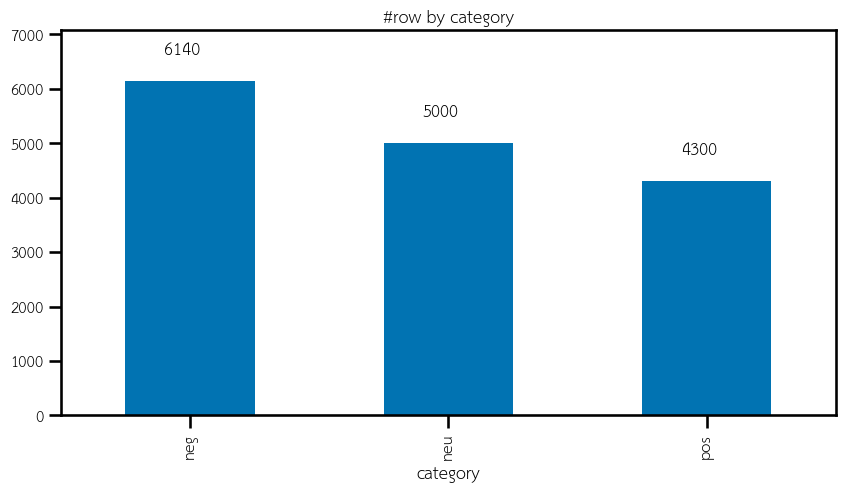

In [26]:
#นับจำนวนข้อมูลในแต่ละประเภท
row_count_by_category = sentiment_df.category.value_counts()

ax = row_count_by_category.plot(
    kind="bar",                      # ✅ ใช้ keyword argument
    title="#row by category",
    figsize=(10, 5)
)

ax.set_ylim(0, row_count_by_category.max() + row_count_by_category.std())

# 🔹 แสดงค่าบนแท่ง
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i - 0.1, label + 500))

plt.show()


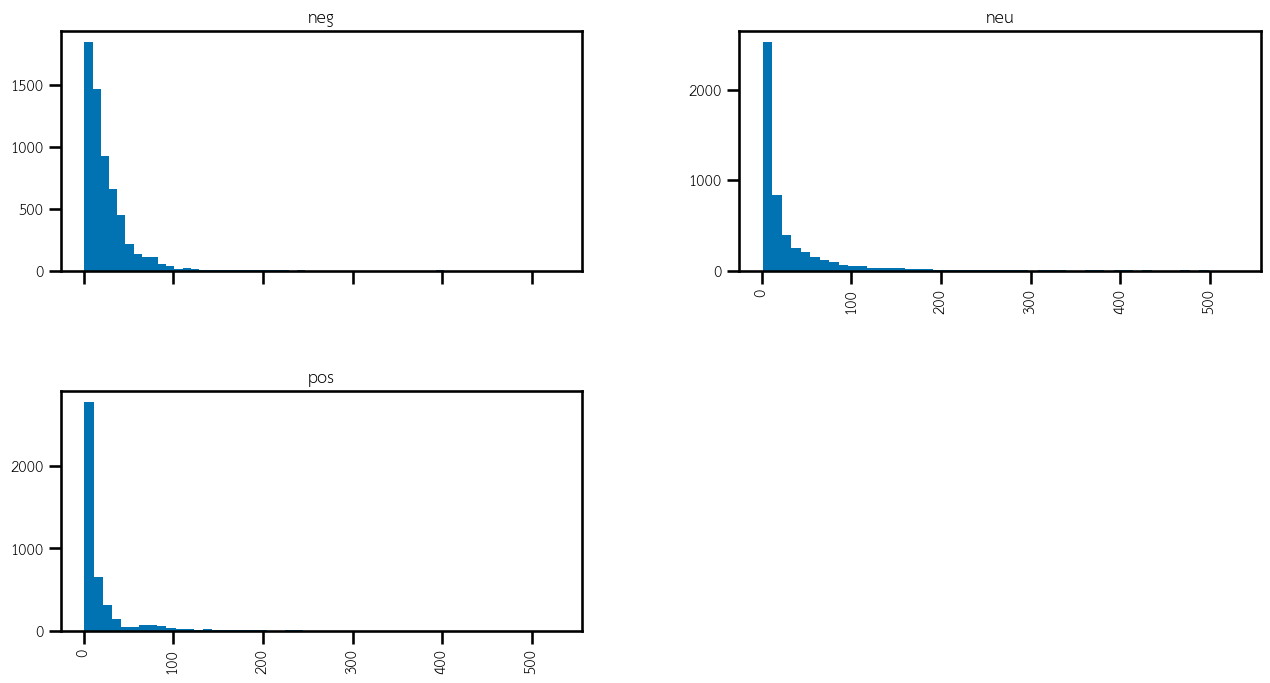

In [27]:
sentiment_df.hist(column="length", by="category", bins=50, figsize=(15, 8), sharex=True)
plt.show()

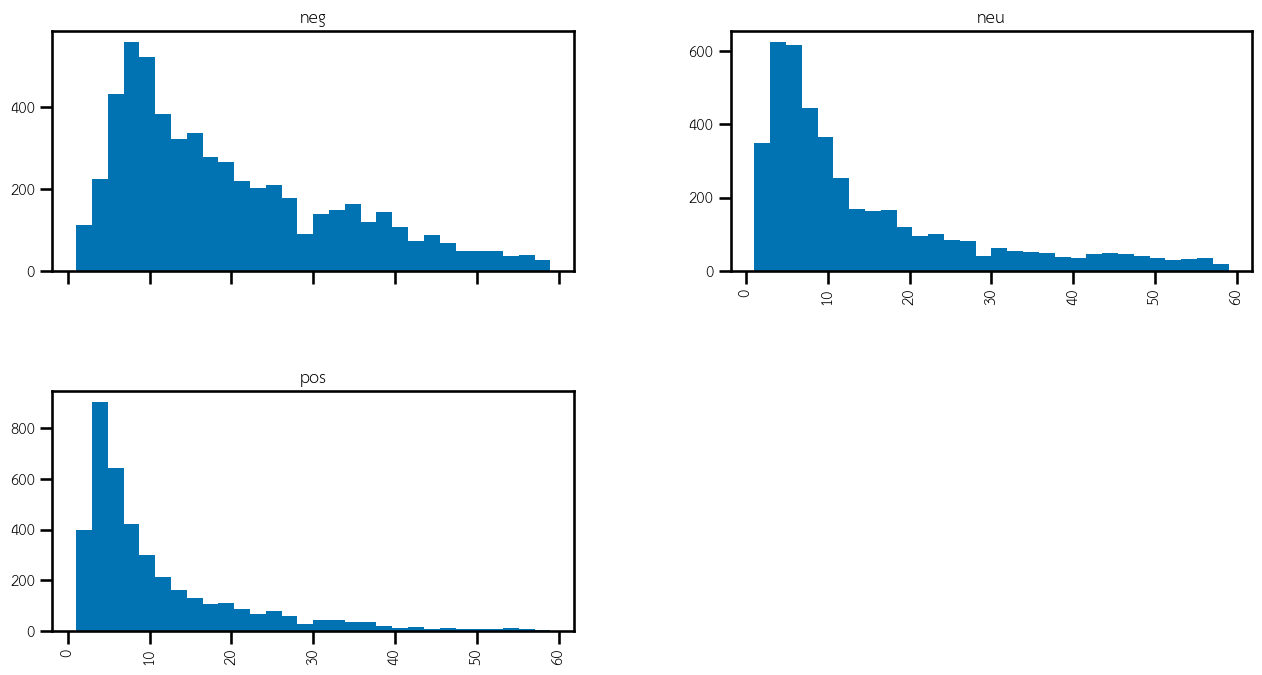

In [28]:
sentiment_df[sentiment_df.length < 60].hist(column="length", by="category", bins=30, figsize=(15, 8), sharex=True)
plt.show()

# Classification

In [29]:
class_names = np.unique(sentiment_df.category).tolist()

## Multinomial Naive Bayes (default parameters)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sentiment_df["texts"], sentiment_df["category"], test_size=0.20, random_state=42)

In [31]:
#สร้างโมเดลการจำแนกประเภทข้อความ
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

#การสร้าง Pipeline
text_clf = Pipeline([
    #แปลงข้อมูลข้อความ (Text) ให้เป็นเวกเตอร์ของจำนวนคำ (Term Count) โดยใช้ฟังก์ชัน process_text ในการ Tokenize และพิจารณา N-gram (คู่คำหรือคำเดี่ยว) ในช่วง (1, 2)
    ("vect", CountVectorizer(tokenizer=process_text, ngram_range=(1,2))), 
    #แปลงเวกเตอร์จำนวนคำจากขั้นตอนที่ 1 ให้เป็นเวกเตอร์ TF-IDF (Term Frequency-Inverse Document Frequency) 
    ("tfidf", TfidfTransformer()),
    #ใช้โมเดล Multinomial Naive Bayes เพื่อเรียนรู้และจำแนกประเภท (Sentiment) โดยมี alpha=0.001 เป็นพารามิเตอร์ปรับเรียบ (Smoothing)
    ("clf", MultinomialNB(alpha=0.001)),
])

#train model
text_clf.fit(X_train, y_train)
text_clf.score(X_test, y_test)

C:\Program Files\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6428108808290155

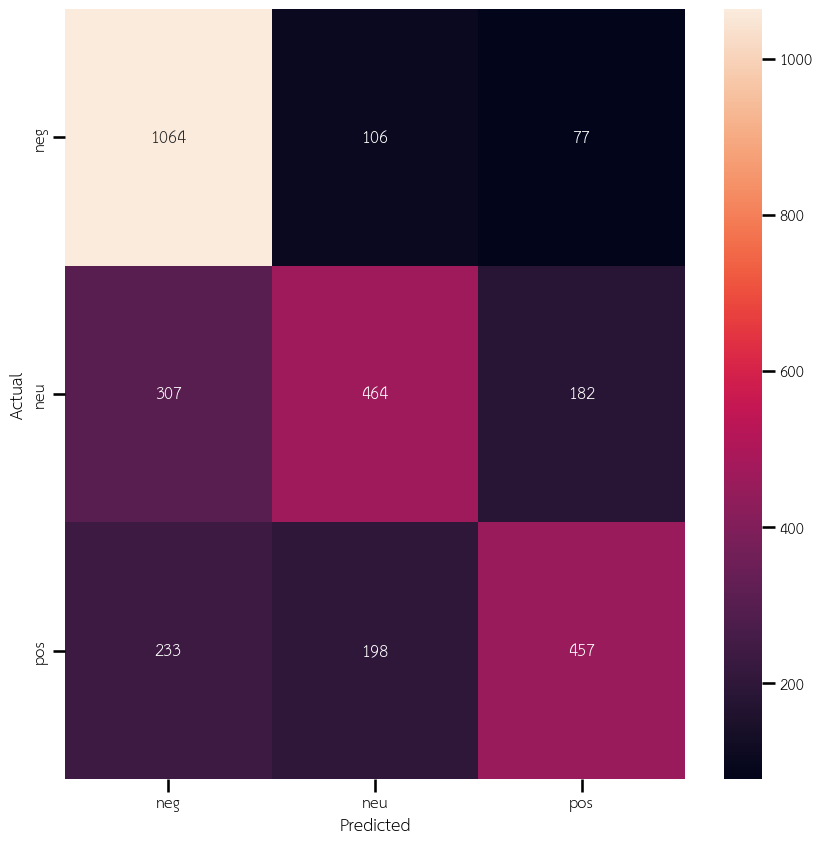

In [32]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, text_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

#### LIME Explainer

In [33]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=class_names)

In [34]:
idx = sentiment_df.sample(1).index[0]

exp = explainer.explain_instance(
    sentiment_df.texts[idx],
    text_clf.predict_proba,
    num_features=5,
    top_labels=1
)

from IPython.display import display, HTML


html = exp.as_html()
styled_html = f"""
<div style="background-color: white; color: black; padding: 20px; border-radius: 10px;">
{html}
</div>
"""

display(HTML(styled_html))


In [ ]:
sentiment_df.iloc[idx]

## Linear SVC (default parameters)

In [35]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svc_clf = Pipeline([
    ("vect", CountVectorizer(tokenizer=process_text, ngram_range=(1,2))),
    ("tfidf", TfidfTransformer()),
    ("clf", LinearSVC()),
])

svc_clf.fit(X_train, y_train)
svc_clf.score(X_test, y_test)

C:\Program Files\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6849093264248705

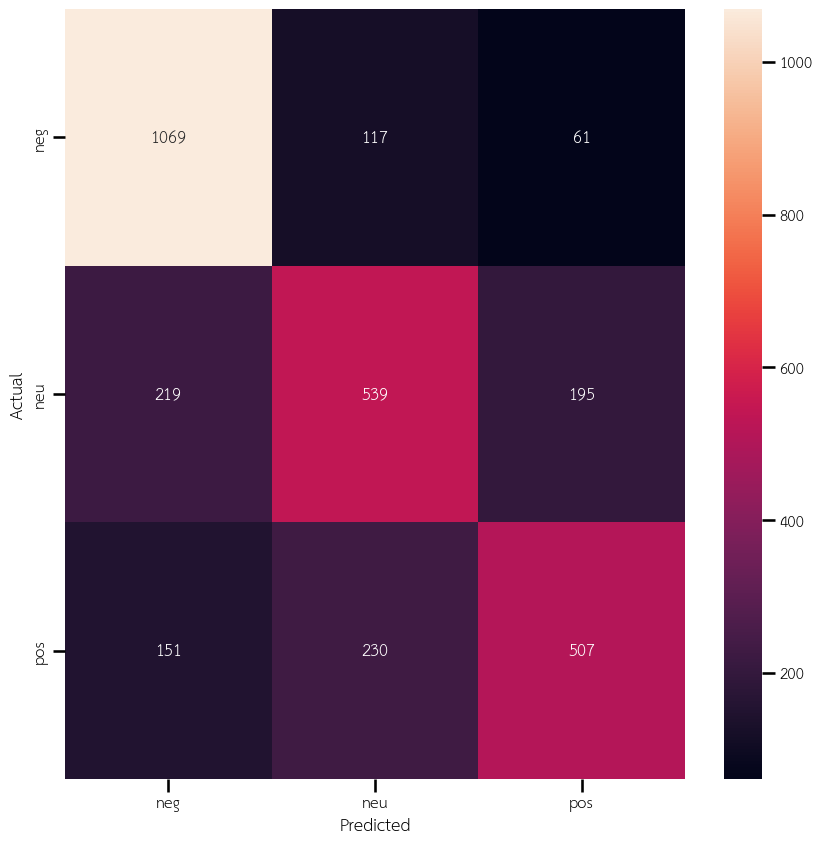

In [36]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, svc_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
##CNN-BiLSTM

In [38]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout

#แปลง labels เป็นตัวเลข
le = LabelEncoder()
y = le.fit_transform(sentiment_df['category'])
y_cat = to_categorical(y)

#แบ่ง train/test
X_train, X_test, y_train, y_test = train_test_split(
    sentiment_df['texts'], y_cat, test_size=0.2, random_state=42
)

#Tokenize ข้อความ
max_words = 10000  # จำนวนคำสูงสุด
max_len = 731      # ความยาวประโยคสูงสุด
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

#สร้างโมเดล CNN-BiLSTM
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 5️⃣ Train โมเดล
history = model.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test),
                    epochs=5, batch_size=64)


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.4275 - loss: 1.0646 - val_accuracy: 0.4870 - val_loss: 1.0143
Epoch 2/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 27s 139ms/step - accuracy: 0.5312 - loss: 0.9706 - val_accuracy: 0.5087 - val_loss: 0.9930
Epoch 3/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 28s 143ms/step - accuracy: 0.6229 - loss: 0.8104 - val_accuracy: 0.5091 - val_loss: 1.0307
Epoch 4/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 28s 144ms/step - accuracy: 0.6802 - loss: 0.6912 - val_accuracy: 0.5094 - val_loss: 1.0844
Epoch 5/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 28s 144ms/step - accuracy: 0.6901 - loss: 0.6428 - val_accuracy: 0.5139 - val_loss: 1.1672


In [43]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# ทำนายผลบนชุดทดสอบ
y_pred_prob = model.predict(X_test_pad)           # ได้เป็น probabilities
y_pred = np.argmax(y_pred_prob, axis=1)          # แปลงเป็น label ตัวเลข
y_true = np.argmax(y_test, axis=1)               # แปลง one-hot เป็น label ตัวเลข

# สร้าง classification report เป็น dict
report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)

# แปลงเป็น DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# แสดงผลเป็นตาราง
report_df


97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


,precision,recall,f1-score,support
neg,0.565938,0.684844,0.619739,1247.000000
neu,0.596354,0.240294,0.342558,953.000000
pos,0.421757,0.567568,0.483917,888.000000
accuracy,0.513925,0.513925,0.513925,0.513925
macro avg,0.528016,0.497568,0.482071,3088.000000
weighted avg,0.533863,0.513925,0.495139,3088.000000


97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


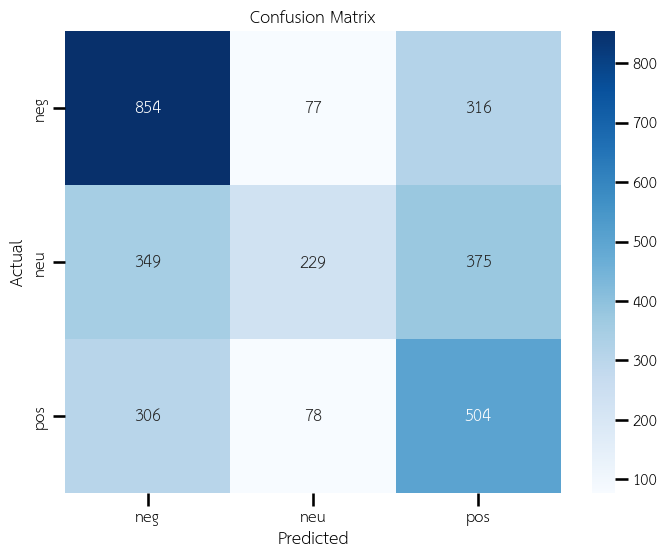

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

#ทำนายผล
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

#สร้าง confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

#วาด heatmap
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d", 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#BiLSTM-CNN

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 146s 748ms/step - accuracy: 0.4290 - loss: 1.0595 - val_accuracy: 0.4641 - val_loss: 1.0058
Epoch 2/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 153s 793ms/step - accuracy: 0.5389 - loss: 0.9407 - val_accuracy: 0.5146 - val_loss: 0.9959
Epoch 3/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 154s 800ms/step - accuracy: 0.6364 - loss: 0.7659 - val_accuracy: 0.5006 - val_loss: 1.0564
Epoch 4/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 155s 801ms/step - accuracy: 0.6661 - loss: 0.6791 - val_accuracy: 0.5185 - val_loss: 1.1632
Epoch 5/5
193/193 ━━━━━━━━━━━━━━━━━━━━ 149s 774ms/step - accuracy: 0.6964 - loss: 0.6192 - val_accuracy: 0.5130 - val_loss: 1.2465
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step
              precision    recall  f1-score   support

         neg       0.57      0.67      0.62      1247
         neu       0.58      0.23      0.33       953
         pos       0.42      0.59      0.49       888

    accuracy                           0.51      3088
   macro avg       0.53      0.5

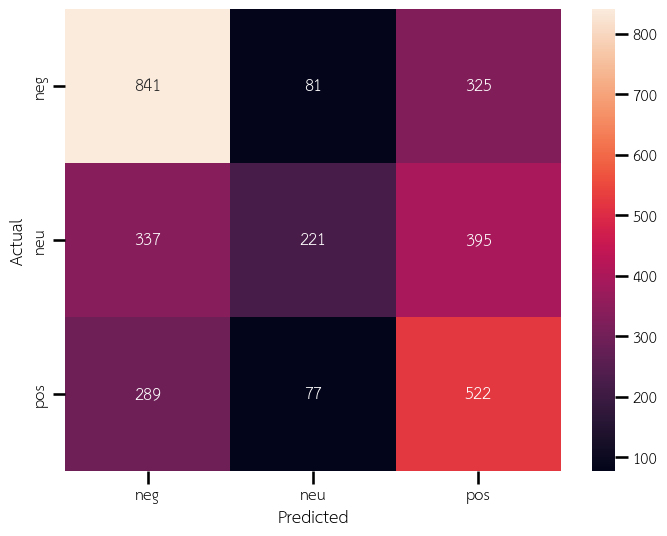

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D

#พารามิเตอร์
max_words = 10000
max_len = 731
embedding_dim = 768

#โมเดล BiLSTM-CNN
bilstm_cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    GlobalMaxPooling1D(),  # <-- แปลง shape เป็น (batch, features)
    Dropout(0.5),
    Dense(y_cat.shape[1], activation='softmax')
])

bilstm_cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
bilstm_cnn_model.summary()

#Train โมเดล
history_bilstm_cnn = bilstm_cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=64
)

#ประเมิน F1-score และ Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ทำนาย
y_pred_prob = bilstm_cnn_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [44]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# ทำนาย
y_pred_prob = bilstm_cnn_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# สร้าง classification report
report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)

# แปลงเป็น DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# แสดงเป็นตาราง
report_df


97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step


,precision,recall,f1-score,support
neg,0.573279,0.674419,0.619749,1247.000000
neu,0.583113,0.231899,0.331832,953.000000
pos,0.420290,0.587838,0.490141,888.000000
accuracy,0.512953,0.512953,0.512953,0.512953
macro avg,0.525561,0.498052,0.480574,3088.000000
weighted avg,0.532320,0.512953,0.493623,3088.000000
